# TDCRPy — Micelle effects

## Stochastic modelling of micellar quenching

Aqueous samples are not soluble in an organic scintillation cocktail. They are
held in suspension as a **water-in-oil microemulsion**: nanometric droplets of
the aqueous phase, each wrapped in a surfactant shell — *reverse micelles* —
dispersed in the scintillating solvent.

A **hydrophilic** tracer is dissolved in those droplets, so every decay starts
*inside* a water core. Water does not scintillate: the fraction of the electron
track that stays in the aqueous phase produces no light at all. The electron
then alternates between the two phases until it stops, and only the path length
travelled in the organic phase contributes to the scintillation signal.

TDCRPy implements this as a **Markovian two-phase transport Monte Carlo**
(`TDCR_model_lib.pure_mc_efficient_energy_numba`, a numba kernel; the
sampled-radius correction of section 2.1 requires TDCRPy **>= 2.20.19**, and
the monodisperse default of section 5 is TDCRPy **>= 2.20.21**)
applied to
every electron and positron after Birks quenching whenever `micCorr = True`:

| Step | Model |
|---|---|
| Electron range | $R(E) = 40\,E^{1.75}$ nm, $E$ in keV (`calc_range_numba`) |
| Micelle size | Gaussian, mean radius `diam_micelle`/2, std `sigma_micelle`, truncated at 0, **re-sampled at every encounter**; the shipped default `sigma_micelle = 0` makes the population monodisperse |
| Starting point | uniform in the volume of a droplet (hydrophilic tracer); the escape chord is solved exactly |
| Organic-phase step | exponential, mean free path $\lambda = \tfrac{4}{3}\,r_d\,(1-f_{Aq})/f_{Aq}$, $r_d$ the droplet radius |
| Aqueous-phase step | isotropic chord through the sphere, $d = 2r\sqrt{u}$ |
| Scored energy | only the residual-range difference accumulated in the **organic** phase |

Because the micelle radius, the starting point and every step length are
*sampled*, the model returns a **distribution** of retained energy, not just a
mean — this is what distinguishes it from the earlier deterministic lookup
(`micelleLoss`, interpolated from the GEANT4-DNA results of
[Nedjadi et al., ARI 125 (2017) 94–107](https://doi.org/10.1016/j.apradiso.2017.04.020)).

### What this notebook does

It quantifies the impact of switching the correction **on** versus **off**, at a
fixed Birks constant `kB = 0.01 cm/MeV`, for five low- to medium-energy
nuclides — **H-3, Fe-55, Cr-51, Ni-63, C-14, Tc-99** — under the calibration
regime that matters in practice:

The efficiencies are computed **TDCR-calibrated**: `L` is re-fitted by
`TDCRPy.eff()` so the model reproduces a measured TDCR ratio, taken from the
self-consistent set built in section 1.1. This is the only regime that corresponds to a real
activity measurement, where `L` is never known a priori but always deduced from
the triple-to-double ratio. Imposing `L` instead would overstate the effect,
because a fixed-`L` comparison counts the part of the correction that
calibration simply reabsorbs.

Section 5 then asks how much of any of this depends on the droplet **size
dispersion**, which the shipped default leaves at zero.

In [1]:
import importlib, warnings, time, io, contextlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from importlib.metadata import version

import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.21


## 1. Configuration of the study

The comparison is **controlled**: cocktail, aqueous fraction, Birks constant and
counter settings are identical in both arms. The *only* thing that changes
between "with" and "without" is the `micCorr` flag.

That matters, because raising `fAq` also changes the density, the effective $Z$
and $A$ and the atomic composition of the mixture, which feed back into the
stopping power. Holding `fAq = 0.10` fixed in both arms isolates the **micellar
geometry** effect from the bulk **dilution** effect (the latter is covered in
[`cocktailComposition.ipynb`](../advanced/cocktailComposition.ipynb)).

| Parameter | Value | Note |
|---|---|---|
| Birks constant `kB` | 0.01 cm/MeV = **1e-5 cm/keV** | TDCRPy takes kB in cm keV⁻¹ |
| Cocktail | Ultima Gold | |
| Aqueous fraction `fAq` | 0.10 | representative 10 % aqueous load |
| Aqueous phase | pure water | |
| `diam_micelle` | **4 nm** (diameter) | config default from 2.20.21; the kernel works with the radius, 2 nm |
| `sigma_micelle` | **0 nm** | config default from 2.20.21: monodisperse. Section 5 varies it |
| Scintillator volume `V` | 10 mL | |
| MC trials `N` | 100 000 | 10x the JCGM 101 minimum, to resolve sub-percent residuals |
| Tracer | hydrophilic | hard-coded in the quenching path |

In [2]:
# ---- study constants ---------------------------------------------------
KB       = 1e-5          # cm/keV  ==  0.01 cm/MeV  (the value requested)
V        = 10            # mL
N_MC     = 100000        # MC trials
FAQ      = 0.10          # aqueous volume fraction
DIAM     = 4             # nm, configured micelle DIAMETER (config default
                         # from 2.20.21; Bergeron 2012 puts commercial
                         # cocktails well below the canonical 8 nm)
R_D      = DIAM / 2      # nm, the droplet RADIUS the kernel works with
SIGMA    = 0.0           # nm, std of the micelle size distribution; 0 is the
                         # config default from 2.20.21 -- monodisperse
COCKTAIL = 'Ultima Gold'
LBOUNDS  = (0.5, 12)     # bracket for the L fit in Regime B -- see section 4.1;
                         # the eff() default (0.1, 100) is NOT safe here

NUCLIDES = ['H-3', 'Fe-55', 'Cr-51', 'Ni-63', 'C-14', 'Tc-99']

# ---- section 5: the size-dispersion scan -------------------------------
# sigma/r_d = 0, 10, 20, 30 % -- the range a narrow size distribution
# covers -- plus the 50 % spread TDCRPy shipped as its default up to
# 2.20.20, kept as an out-of-range reference.
SIGMA_SCAN = [0.0, 0.2, 0.4, 0.6]
SIGMA_WIDE = 1.0
SIGMA_TEST = max(SIGMA_SCAN)   # spread used for the calibrated test of 5.3
N_REC      = 20000             # decays recorded per nuclide in section 5.2

# Mean energy of the electrons that carry the signal (annotation only).
E_MEAN = {'H-3': 5.7, 'Fe-55': 5.2, 'Cr-51': 4.4,
          'Ni-63': 17.4, 'C-14': 49.5, 'Tc-99': 84.6}

# The measured TDCR ratios. Three are measurements; the other three are the
# ratios the SAME counter would read, obtained from the light yield fitted to
# their anchor (section 1.1). This keeps the whole set internally consistent
# instead of mixing counters.
TD_GIVEN  = {'Tc-99': 0.98, 'C-14': 0.97, 'Fe-55': 0.57}
TD_ANCHOR = {'H-3': 'C-14', 'Ni-63': 'C-14', 'Cr-51': 'Fe-55'}

INFO = {}        # rad -> (TD, <E_e> keV); filled by section 1.1
N_INFER = 20000  # trials for the inference: TD good to ~1e-3, and it is an
                 # input to the study, not one of its results
COLORS = {'H-3': '#d62728', 'Fe-55': '#ff7f0e', 'Cr-51': '#8c564b',
          'Ni-63': '#2ca02c', 'C-14': '#1f77b4', 'Tc-99': '#9467bd'}

# Electron-capture nuclides: their signal is carried by Auger electrons at a
# well-defined energy, so a vertical marker on an energy axis is meaningful.
# For the beta emitters the electron energy is broadly distributed and a line
# at the mean would mislead, so they get no marker.
EC_NUCLIDES = ['Fe-55', 'Cr-51']

# ---- remember the nominal config so it can be restored at the end -------
NOMINAL = dict(ls_cocktail='Ultima Gold', fAq=tl.fAq, solvantType=tl.solvantType,
               solvantConc=tl.solvantConc, micCorr=tl.micCorr,
               diam_micelle=tl.diam_micelle, sigma_micelle=tl.sigma_micelle)
print('Nominal config captured:', NOMINAL)


def relchange(a, b):
    '''Relative change from a to b, in percent.'''
    return 100.0 * (b - a) / a if a else np.nan


def _quiet(fn, *a, **kw):
    '''Run fn(*a, **kw) swallowing the parameter dump TDCRPy prints.'''
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*a, **kw)


def set_state(micCorr, fAq=FAQ, diam=DIAM, sigma=SIGMA):
    '''Write the config, then reload so the module-level defaults follow.

    tl.pure_mc_efficient_energy_numba() binds fAq / diam_micelle /
    sigma_micelle as *keyword defaults* evaluated at import time, so a bare
    modify*() call is not enough -- the module has to be reloaded.'''
    global tl, tm
    _quiet(tl.modifyLScocktail, COCKTAIL, float(fAq), 'Water', 0.0)
    tl.modifyDiam_micelle(diam)
    tl.modifySigma_micelle(sigma)
    tl.modifyMicCorr(bool(micCorr))
    tl = importlib.reload(tl)
    tm = importlib.reload(tm)


set_state(False)
print(f'\nActive scintillator: {COCKTAIL} + {FAQ:.0%} water '
      f'-> rho={tl.RHO:.4f} g/cm3, Z={tl.Z:.4f}, A={tl.A:.4f}')
print(f'Micelle parameters : diam={tl.diam_micelle} nm, sigma={tl.sigma_micelle} nm, '
      f'fAq={tl.fAq}')

Nominal config captured: {'ls_cocktail': 'Ultima Gold', 'fAq': 0.0, 'solvantType': 'Water', 'solvantConc': 0.0, 'micCorr': False, 'diam_micelle': 4.0, 'sigma_micelle': 0.0}



Active scintillator: Ultima Gold + 10% water -> rho=0.9818 g/cm3, Z=3.2597, A=5.9509
Micelle parameters : diam=4.0 nm, sigma=0.0 nm, fAq=0.1


### 1.1 Building a self-consistent set of measured TDCR ratios

A TDCR ratio is a property of *a counter measuring a nuclide*, so quoting six
ratios from six different sources would describe six different instruments. The
set used here is built from one instrument instead.

Three ratios are taken as measured: **Tc-99 = 0.98**, **C-14 = 0.97** and
**Fe-55 = 0.57**. Each of the remaining three is then computed as the ratio the
*same* counter would read, by fitting the light yield `L` to an anchor nuclide
and evaluating the model at that `L`:

| nuclide | TD | origin |
|---|---|---|
| Tc-99 | 0.98 | measured |
| C-14 | 0.97 | measured |
| Fe-55 | 0.57 | measured |
| H-3 | inferred | at the `L` fitted to C-14 |
| Ni-63 | inferred | at the `L` fitted to C-14 |
| Cr-51 | inferred | at the `L` fitted to Fe-55 |

The fits use the **uncorrected** model (`micCorr = False`), which is the
conventional TDCR analysis and therefore the natural definition of "what the
counter reads". The correction is then switched on and off against this fixed
set of measurements, exactly as it would be in practice.

A useful check falls out of it: C-14 at 0.97 and Fe-55 at 0.57 are independent
inputs, so the two light yields they imply need not agree — and they nearly do,
which says the two quoted ratios are mutually consistent with one counter.

In [3]:
def _tdcr_replay(rad, L):
    o = tm.TDCRPy(L, rad, '1', N_INFER, KB, V, readRecHist=True)
    return o[4] / o[2] if o[2] > 0 else np.nan


def _fit_L(rad, target):
    '''Light yield reproducing a measured TDCR, from cached decay histories.'''
    tm.TDCRPy(2.0, rad, '1', N_INFER, KB, V, record=True)
    res = opt.minimize_scalar(lambda L: (_tdcr_replay(rad, L) - target) ** 2,
                              bounds=LBOUNDS, method='bounded',
                              options={'maxiter': 60})
    return res.x, _tdcr_replay(rad, res.x)


set_state(False)                      # the uncorrected model defines the counter

L_anchor = {}
for rad in sorted(set(TD_ANCHOR.values())):
    t0 = time.time()
    L_anchor[rad], got = _fit_L(rad, TD_GIVEN[rad])
    assert abs(got - TD_GIVEN[rad]) < 1e-4, f'{rad}: anchor fit did not converge'
    print(f'anchor {rad:6s} TD={TD_GIVEN[rad]:.3f} -> L = {L_anchor[rad]:7.4f} '
          f'(model TD {got:.5f})   [{time.time()-t0:.0f} s]', flush=True)

INFO = {rad: (td, E_MEAN[rad]) for rad, td in TD_GIVEN.items()}
for rad, anchor in TD_ANCHOR.items():
    t0 = time.time()
    tm.TDCRPy(2.0, rad, '1', N_INFER, KB, V, record=True)
    INFO[rad] = (round(float(_tdcr_replay(rad, L_anchor[anchor])), 4), E_MEAN[rad])
    print(f'  {rad:6s} at L({anchor}) = {L_anchor[anchor]:.4f} -> '
          f'TD = {INFO[rad][0]:.4f}   [{time.time()-t0:.0f} s]', flush=True)

spread = max(L_anchor.values()) / min(L_anchor.values()) - 1
print(f'\nthe two anchors imply light yields within {100*spread:.1f} % of each '
      f'other\n')
print(f'{"nuclide":8s} {"TD":>7s} {"<E_e> keV":>10s}   origin')
print('-' * 52)
for rad in NUCLIDES:
    origin = ('measured' if rad in TD_GIVEN
              else f'inferred at L({TD_ANCHOR[rad]})')
    print(f'{rad:8s} {INFO[rad][0]:7.4f} {INFO[rad][1]:10.1f}   {origin}')

anchor C-14   TD=0.970 -> L =  6.0956 (model TD 0.97000)   [28 s]


anchor Fe-55  TD=0.570 -> L =  5.5901 (model TD 0.57000)   [303 s]


  H-3    at L(C-14) = 6.0956 -> TD = 0.6683   [34 s]


  Ni-63  at L(C-14) = 6.0956 -> TD = 0.8806   [28 s]


  Cr-51  at L(Fe-55) = 5.5901 -> TD = 0.4770   [303 s]



the two anchors imply light yields within 9.0 % of each other

nuclide       TD  <E_e> keV   origin
----------------------------------------------------
H-3       0.6683        5.7   inferred at L(C-14)
Fe-55     0.5700        5.2   measured
Cr-51     0.4770        4.4   inferred at L(Fe-55)
Ni-63     0.8806       17.4   inferred at L(C-14)
C-14      0.9700       49.5   measured
Tc-99     0.9800       84.6   measured


## 2. Microscopic response of the micellar model

Before looking at detection efficiencies it is worth seeing what the kernel
actually does to a single electron. The quantity to watch is the **retention
factor**

$$ f(E) \;=\; \frac{\langle E_{\text{organic}}\rangle}{E} $$

the fraction of the electron's energy deposited in the scintillating phase, and
therefore converted into light.

60 energies x 40000 samples in 19.4 s


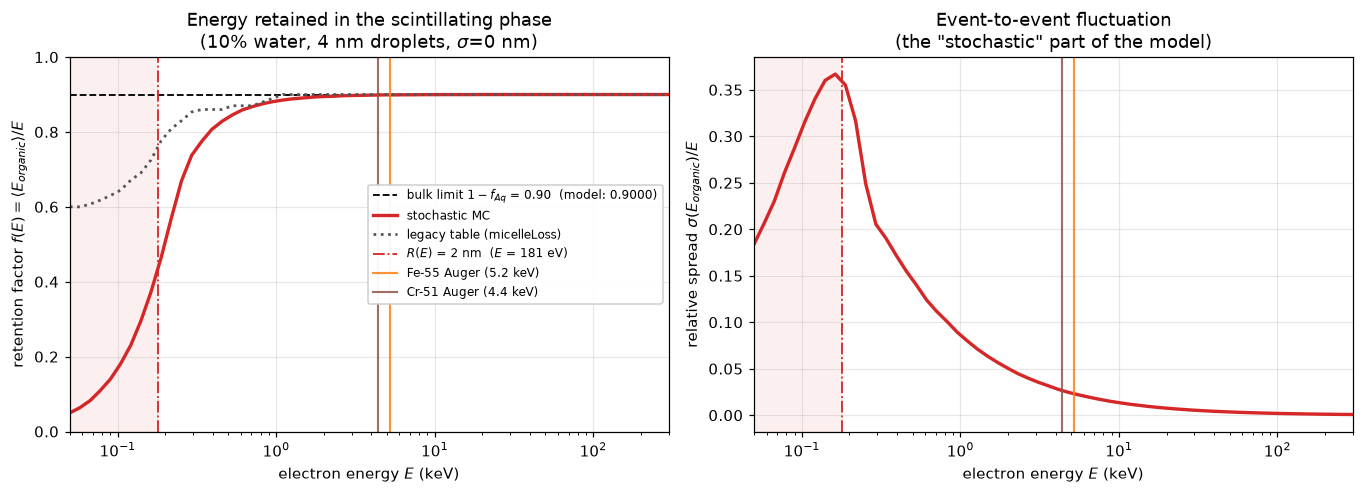

  E (keV)    R(E) (nm)     R/r_d      f(E)    table   sigma/E
     0.05          0.2      0.11    0.0500   0.6000    0.1842
     0.10          0.7      0.36    0.1659   0.6400    0.3063
     0.20          2.4      1.20    0.5080   0.8000    0.3435
     0.50         11.9      5.95    0.8407   0.8700    0.1438
     1.00         40.0     20.00    0.8826   0.9000    0.0863
     2.00        134.5     67.27    0.8949   0.9000    0.0501
     5.20        716.3    358.13    0.8990   0.9000    0.0232
     5.70        841.1    420.54    0.8992   0.9000    0.0215
    17.40       5929.5   2964.77    0.9000   0.9000    0.0085
    49.50      36950.4  18475.20    0.9000   0.9000    0.0035


    84.60      94397.0  47198.49    0.9000   0.9000    0.0022


In [4]:
mc = tl.pure_mc_efficient_energy_numba
NS = 40000                                   # samples per energy point
E_vec = np.logspace(np.log10(0.05), np.log10(300), 60)

f_hydro = np.empty_like(E_vec); s_hydro = np.empty_like(E_vec)
f_table = np.empty_like(E_vec)

t0 = time.time()
for i, E in enumerate(E_vec):
    m, s, _ = mc(E, r_d_nm=R_D, sigma_r=SIGMA, f_w=FAQ, num_samples=NS)
    f_hydro[i], s_hydro[i] = m / E, s / E
    f_table[i] = tl.micelleLoss(E)           # legacy deterministic lookup
print(f'{len(E_vec)} energies x {NS} samples in {time.time()-t0:.1f} s')

# Plateau the model actually reaches at high energy. It sits slightly below
# 1-fAq; section 2.1 explains why.
f_plateau = float(np.mean(f_hydro[E_vec > 100]))

# Energy at which the electron range equals the micelle radius: R(E) = 40*E^1.75
E_conf = (R_D / 40.0) ** (1 / 1.75)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
ax.axvspan(E_vec[0], E_conf, color='#d62728', alpha=0.07)
ax.axhline(1 - FAQ, color='k', ls='--', lw=1.2,
           label=rf'bulk limit $1-f_{{Aq}}$ = {1-FAQ:.2f}'
                 f'  (model: {f_plateau:.4f})')
ax.plot(E_vec, f_hydro, '-', color='#d62728', lw=2.2, label='stochastic MC')
ax.plot(E_vec, f_table, ':', color='#555555', lw=1.8, label='legacy table (micelleLoss)')
ax.axvline(E_conf, color='#d62728', lw=1.2, ls='-.',
           label=f'$R(E)$ = {R_D:g} nm  ($E$ = {E_conf*1e3:.0f} eV)')
# Markers only for the EC nuclides, whose signal sits at a well-defined Auger
# energy; a beta emitter's energy is distributed, so a line at its mean would
# mislead rather than inform.
for rad in EC_NUCLIDES:
    ax.axvline(INFO[rad][1], color=COLORS[rad], lw=1.4, alpha=0.85,
               label=f'{rad} Auger ({INFO[rad][1]:.1f} keV)')
ax.set_xscale('log'); ax.set_xlabel('electron energy $E$ (keV)')
ax.set_ylabel(r'retention factor $f(E)=\langle E_{organic}\rangle/E$')
ax.set_ylim(0, 1.0); ax.set_xlim(E_vec[0], E_vec[-1])
ax.set_title('Energy retained in the scintillating phase\n'
             f'({FAQ:.0%} water, {DIAM:g} nm droplets, $\\sigma$={SIGMA:g} nm)')
ax.legend(fontsize=8, loc='center right', framealpha=0.95); ax.grid(alpha=0.3)

ax = axes[1]
ax.axvspan(E_vec[0], E_conf, color='#d62728', alpha=0.07)
ax.plot(E_vec, s_hydro, '-', color='#d62728', lw=2.2)
ax.axvline(E_conf, color='#d62728', lw=1.2, ls='-.')
for rad in EC_NUCLIDES:
    ax.axvline(INFO[rad][1], color=COLORS[rad], lw=1.4, alpha=0.85)
ax.set_xscale('log'); ax.set_xlabel('electron energy $E$ (keV)')
ax.set_ylabel(r'relative spread $\sigma(E_{organic})/E$')
ax.set_xlim(E_vec[0], E_vec[-1])
ax.set_title('Event-to-event fluctuation\n(the "stochastic" part of the model)')
ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('micelle_retention.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"E (keV)":>9s} {"R(E) (nm)":>12s} {"R/r_d":>9s} {"f(E)":>9s} '
      f'{"table":>8s} {"sigma/E":>9s}')
for E in [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.2, 5.7, 17.4, 49.5, 84.6]:
    m, s, _ = mc(E, r_d_nm=R_D, sigma_r=SIGMA, f_w=FAQ, num_samples=NS)
    R = tl.calc_range_numba(E)
    print(f'{E:9.2f} {R:12.1f} {R/R_D:9.2f} {m/E:9.4f} '
          f'{tl.micelleLoss(E):8.4f} {s/E:9.4f}')

**One tracer geometry, because only one occurs in practice.** An aqueous sample
enters an organic cocktail as reverse micelles, and the tracer goes with the
water — so the decay always starts inside a droplet. The mirror case, a
lipophilic tracer dissolved directly in the solvent, is not a configuration you
would ever set up alongside an aqueous fraction: with no water loaded there are
no micelles and nothing to correct. TDCRPy's quenching path reflects this, since
it calls the kernel with its `tracer_type='hydrophilic'` default and offers no
way to change it. Everything below is that single, physical case.

**Two regimes, separated by the electron range.**

* $E \gtrsim 3$ keV — the range ($\gtrsim 250$ nm, more than a hundred droplet
  radii) is far larger than a micelle. The track crosses many droplets and
  samples both phases in proportion to their volumes, so $f(E)$ saturates at the
  bulk limit $1-f_{Aq} = 0.90$: the correction degenerates into a flat 10 % cut
  in light yield, and where the track *started* no longer matters. This is what
  the legacy lookup assumes at every energy.
* $E \lesssim 3$ keV — the range becomes comparable to the droplet and the
  starting point dominates. The electron is *born inside water* and may never
  reach the solvent at all: $f$ falls below the bulk limit, and once the range
  drops under the micelle radius (shaded, left of the dash-dotted line) the
  electron is essentially trapped, with $f \to 0$. **This confinement penalty is
  the genuinely new physics the correction brings**, and it is precisely where
  the legacy table is blind.

The six nuclides of this study all have mean electron energies in the plateau,
so for their *bulk* behaviour the correction is close to a uniform $1-f_{Aq}$
rescaling. What separates them is how much of each spectrum reaches down into
the shaded region — which is why Fe-55, carried by Auger electrons of a few keV
and below, behaves differently from the β emitters in sections 3 and 4.

The right-hand panel shows the second novelty: the correction is not a
deterministic rescaling. It injects a per-decay dispersion of the retained
energy that peaks in the confinement regime, which broadens the photoelectron
distribution and therefore acts on the *triple-to-double ratio*, not only on the
mean light output.

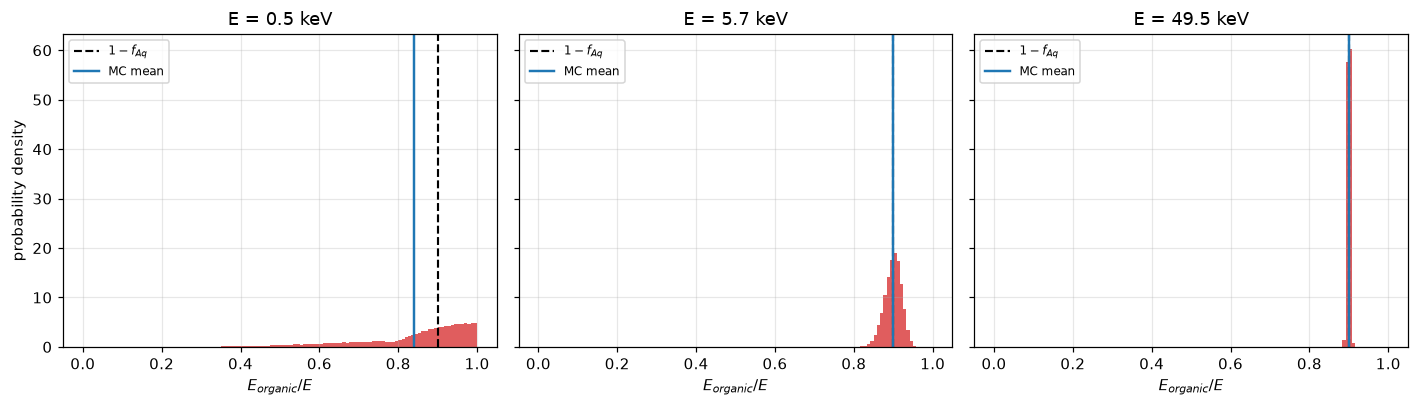

In [5]:
# Per-event distribution of the retained energy -- the deterministic table
# would be a single vertical line at 1 - fAq.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, E in zip(axes, [0.5, 5.7, 49.5]):
    _, _, samp = mc(E, r_d_nm=R_D, sigma_r=SIGMA, f_w=FAQ, num_samples=200000)
    ax.hist(samp / E, bins=120, range=(0, 1), color='#d62728', alpha=0.75, density=True)
    ax.axvline(1 - FAQ, color='k', ls='--', lw=1.4, label=r'$1-f_{Aq}$')
    ax.axvline(np.mean(samp) / E, color='#1f77b4', lw=1.6, label='MC mean')
    ax.set_xlabel(r'$E_{organic}/E$'); ax.set_title(f'E = {E} keV')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel('probability density')
plt.tight_layout(); plt.savefig('micelle_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

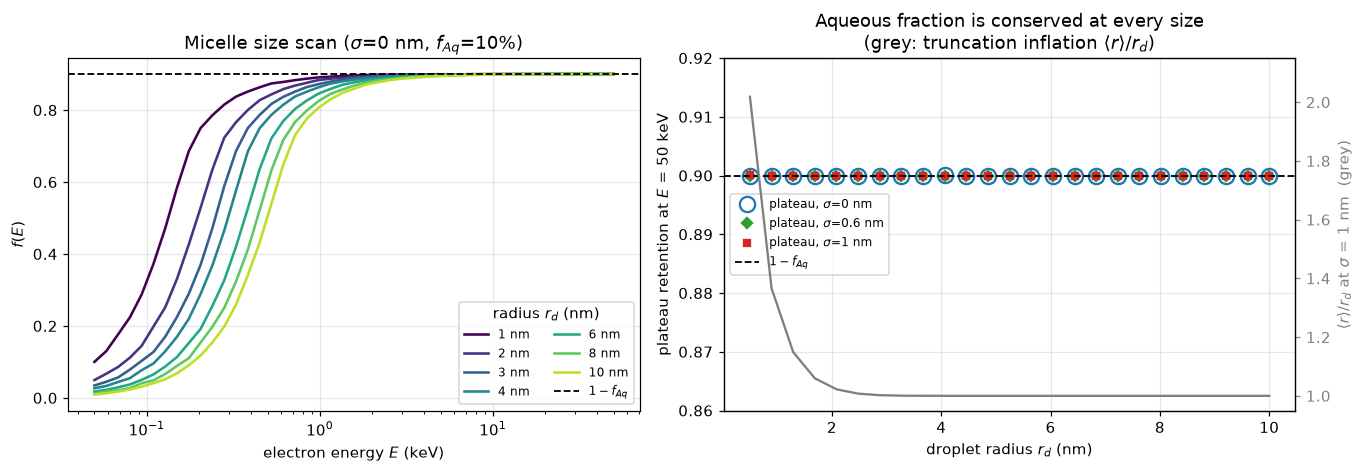

  r_d  sigma     <r>   <r>/r_d   plateau    1-fAq
--------------------------------------------------


    1    0.0  1.0000    1.0000    0.9000   0.9000


    1    0.6  1.0627    1.0627    0.9000   0.9000


    1    1.0  1.2876    1.2876    0.9000   0.9000


    2    0.0  2.0000    1.0000    0.9000   0.9000


...

    3    1.0  3.0044    1.0015    0.9000   0.9000
    4    0.0  4.0000    1.0000    0.9000   0.9000


    4    0.6  4.0000    1.0000    0.9000   0.9000
    4    1.0  4.0001    1.0000    0.9000   0.9000


    6    0.0  6.0000    1.0000    0.9000   0.9000
    6    0.6  6.0000    1.0000    0.8999   0.9000


    6    1.0  6.0000    1.0000    0.8999   0.9000
    8    0.0  8.0000    1.0000    0.8999   0.9000
    8    0.6  8.0000    1.0000    0.8999   0.9000


    8    1.0  8.0000    1.0000    0.8999   0.9000


In [6]:
# Left : retention vs energy for a range of droplet RADII (the kernel's
#        r_d_nm; the configured diam_micelle is twice this).
# Right: why those curves do not all land on 1-fAq (see the markdown below).
from scipy.stats import norm

diam_vec = np.array([1, 2, 3, 4, 6, 8, 10])
E_sub = np.logspace(np.log10(0.05), np.log10(50), 45)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

cmap = plt.cm.viridis(np.linspace(0, 0.9, len(diam_vec)))
for c, d in zip(cmap, diam_vec):
    y = [mc(E, r_d_nm=d, sigma_r=SIGMA, f_w=FAQ, num_samples=20000)[0] / E
         for E in E_sub]
    axes[0].plot(E_sub, y, '-', color=c, lw=1.7, label=f'{d} nm')
axes[0].axhline(1 - FAQ, color='k', ls='--', lw=1.2, label=r'$1-f_{Aq}$')
axes[0].set_xscale('log'); axes[0].set_xlabel('electron energy $E$ (keV)')
axes[0].set_ylabel(r'$f(E)$')
axes[0].set_title(f'Micelle size scan ($\\sigma$={SIGMA:g} nm, $f_{{Aq}}$={FAQ:.0%})')
axes[0].legend(fontsize=8, title='radius $r_d$ (nm)', ncol=2,
               loc='lower right')
axes[0].grid(alpha=0.3)

# --- the plateau must now sit at 1-fAq for every size (v2.20.19) -----------
r_fine = np.linspace(0.5, 10, 25)
for s, col, mk, ms, fc in ((0.0, '#1f77b4', 'o', 10, 'none'),
                          (SIGMA_TEST, '#2ca02c', 'D', 5, '#2ca02c'),
                          (SIGMA_WIDE, '#d62728', 's', 4, '#d62728')):
    meas = [mc(50.0, r_d_nm=r, sigma_r=s, f_w=FAQ, num_samples=40000)[0] / 50.0
            for r in r_fine]
    axes[1].plot(r_fine, meas, mk, color=col, ms=ms, ls='none', markerfacecolor=fc, markeredgewidth=1.5,
                 label=f'plateau, $\\sigma$={s:g} nm')
axes[1].axhline(1 - FAQ, color='k', ls='--', lw=1.2, label=r'$1-f_{Aq}$')

# the inflation factor that the fix corrects for, on a second axis
ax2 = axes[1].twinx()
ax2.plot(r_fine, [tl.mean_truncated_radius(r, SIGMA_WIDE) / r for r in r_fine],
         '-', color='#7f7f7f', lw=1.5)
ax2.set_ylabel(r'$\langle r\rangle / r_d$ at $\sigma$ = 1 nm  (grey)',
               color='#7f7f7f')
ax2.tick_params(axis='y', colors='#7f7f7f')
ax2.set_ylim(0.95, 2.15)

axes[1].set_xlabel('droplet radius $r_d$ (nm)')
axes[1].set_ylabel('plateau retention at $E$ = 50 keV')
axes[1].set_ylim(0.86, 0.92)
axes[1].set_title('Aqueous fraction is conserved at every size\n'
                  r'(grey: truncation inflation $\langle r\rangle/r_d$)')
axes[1].legend(fontsize=8, loc='center left'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('micelle_scans.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"r_d":>5s} {"sigma":>6s} {"<r>":>7s} {"<r>/r_d":>9s} '
      f'{"plateau":>9s} {"1-fAq":>8s}')
print('-' * 50)
for r in (1, 2, 3, 4, 6, 8):
    for s in (0.0, SIGMA_TEST, SIGMA_WIDE):
        Er = tl.mean_truncated_radius(float(r), s)
        meas = mc(50.0, r_d_nm=r, sigma_r=s, f_w=FAQ, num_samples=60000)[0] / 50.0
        print(f'{r:5d} {s:6.1f} {Er:7.4f} {Er/r:9.4f} {meas:9.4f} {1-FAQ:8.4f}')

### 2.1 Conserving the aqueous fraction: the sampled-radius correction

A subtlety worth spelling out, because it was wrong until TDCRPy **2.20.19**. It no longer bites at the shipped settings — the default is monodisperse from 2.20.21, and a zero spread makes the sampled radius exactly the nominal one — but it governs everything section 5 does with $\sigma > 0$.
The micelle radius enters the kernel in two places, and they must be the same
radius:

* the **organic** mean free path,
  $\lambda = \tfrac{4}{3}\,\bar{r}\,(1-f_{Aq})/f_{Aq}$;
* each **aqueous** crossing, a chord of the sampled droplet
  $d = 2r\sqrt{u}$ with $r \sim \mathcal{N}(r_d, \sigma)$ **truncated at zero**
  (`get_micelle_radius` redraws while $r \le 0$), giving
  $\langle d \rangle = \tfrac{4}{3}\langle r \rangle$.

Truncation makes the radii actually drawn larger than the nominal value,

$$\langle r\rangle = r_d + \sigma\,\frac{\varphi(a)}{1-\Phi(a)},
  \qquad a = -\frac{r_d}{\sigma}$$

by a margin that matters only when $\sigma$ is comparable to $r_d$: at
$r_d = 1$ nm with $\sigma = 1$ nm, $\langle r\rangle = 1.288$ nm — 29 % high.

Until 2.20.19 the mean free path was built from the *nominal* $r_d$ while the
chords used the *sampled* radius. The aqueous path fraction was therefore
inflated by exactly $\langle r\rangle/r_d$, and the high-energy plateau fell
below the volume-fraction limit: **0.8748 instead of 0.9000** at $r_d = 1$ nm
(2.8 % too much quenching), 0.8975 at $r_d = 2$ nm — the default droplet radius, half the configured 4 nm diameter — and
converging to 0.9000 only for $r_d \gtrsim 3$ nm. The model was quenching more
than the requested `fAq` asked for, and the error grew as the micelles got
smaller relative to their spread.

The fix (`mean_truncated_radius`) builds $\lambda$ from $\langle r\rangle$
instead, so the two radii agree and the aqueous path fraction collapses to
$f_{Aq}$ exactly:

$$f_\infty = 1 - \frac{\tfrac{4}{3}\langle r\rangle}
      {\tfrac{4}{3}\langle r\rangle\frac{1-f_{Aq}}{f_{Aq}}
       + \tfrac{4}{3}\langle r\rangle} = 1 - f_{Aq}$$

independent of $r_d$ and $\sigma$. The right-hand panel above confirms it: every
size lands on $1-f_{Aq}$ at $\sigma = 0$ (the default), at $\sigma = 0.6$ nm and
at the $\sigma = 1$ nm that TDCRPy shipped up to 2.20.20 — the grey curve shows
how large the truncation inflation being corrected for gets at that last one.

What $\sigma$ still does, once the mean is protected this way, is shape the
*spread* of the retained energy, and — where the electron is confined — pull its
mean up by convexity rather than truncation. Section 5 measures both.

## 3. TDCR-calibrated efficiencies — `eff()` optimisation at typical TD values

In a real measurement `L` is never imposed: it is *deduced* from the measured
triple-to-double ratio. `TDCRPy.eff(TD, ...)` does exactly that — it runs one MC
pass with `record=True`, bounded-scalar-minimises
$(T/D|_{\text{model}} - TD|_{\text{meas}})^2$ over `L`, then re-evaluates the
efficiencies at the optimum from the cached decay histories.

The micelle correction is applied to the *quenched* energies **before** they are
recorded, so it sits fully inside the loop: enabling it drives the optimiser to
a different `L`.

Because the TD set of section 1.1 describes a single counter, the fitted `L`
should now come out close to the same value for every nuclide in the
`micCorr = False` arm — a consistency check the previous, heterogeneous set
could not provide.

The TD values are the self-consistent set built in section 1.1 — three
measured, three inferred from the light yield of their anchor — so all six
describe the same counter.

### 3.1 The calibration curve, and why `Lbounds` has to be chosen with care

`eff()` minimises over `L` with `scipy.optimize.minimize_scalar(method='bounded')`
— a golden-section/parabolic search that assumes the residual is **unimodal**
inside the bracket. The curve below shows it is not: for Fe-55 the modelled
TDCR ratio *turns over* around $L \approx 20$ photons/keV and decreases again,
so the residual grows a second, spurious minimum against the upper bound. With
the `eff()` default `Lbounds=(0.1, 100)` the search walks into it and returns
`L ≈ 66` with a fitted TDCR of 0.95 instead of the requested 0.40 — **silently**,
since nothing in the return value flags a failed fit.

The curves are computed with the `record` → `readRecHist` trick: one MC pass per
case, then a pure replay at each `L`, which is what `objectFct` does internally.

The turnover is not a numerical artefact. Fe-55 emits Mn K X-rays that
frequently escape the counting volume, leaving a large population of very small
energy deposits. As `L` grows, those events are progressively recovered by the
*doubles* long before they can fire three PMTs, so `eff_D` climbs toward 1
faster than `eff_T` and their ratio falls. Any nuclide with a substantial
near-zero-deposit population will do the same.

H-3    calibration curves done


Fe-55  calibration curves done


Cr-51  calibration curves done


Ni-63  calibration curves done


C-14   calibration curves done


Tc-99  calibration curves done


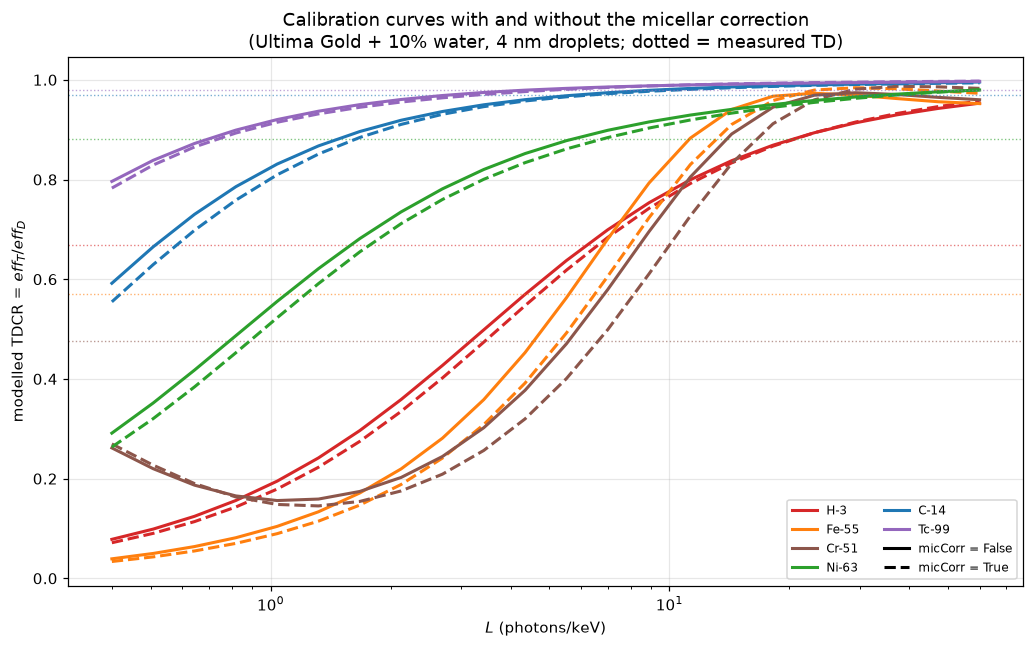

L at which the modelled TDCR peaks (micCorr=False):
  H-3      60.00 photons/keV  (max TDCR = 0.9531)
  Fe-55    23.10 photons/keV  (max TDCR = 0.9730)
  Cr-51    29.33 photons/keV  (max TDCR = 0.9741)
  Ni-63    60.00 photons/keV  (max TDCR = 0.9795)
  C-14     60.00 photons/keV  (max TDCR = 0.9956)
  Tc-99    60.00 photons/keV  (max TDCR = 0.9969)

vertical shift of the calibration curve at L = 8.0 photons/keV
nuclide   TDCR off   TDCR on   shift %
---------------------------------------
H-3         0.7277    0.7146     -1.80
Fe-55       0.7398    0.6676     -9.75
Cr-51       0.6404    0.5577    -12.91
Ni-63       0.9076    0.8942     -1.47
C-14        0.9767    0.9747     -0.20
Tc-99       0.9868    0.9862     -0.06


In [7]:
N_CAL = 3000                                   # lighter: this is a shape study
L_grid = np.logspace(np.log10(0.4), np.log10(60), 22)

calib = {}
for rad in NUCLIDES:
    for mic in (False, True):
        set_state(mic)
        tm.TDCRPy(2.0, rad, '1', N_CAL, KB, V, record=True)   # cache histories
        td = []
        for Lg in L_grid:
            o = tm.TDCRPy(Lg, rad, '1', N_CAL, KB, V, readRecHist=True)
            td.append(o[4] / o[2] if o[2] > 0 else np.nan)
        calib[(rad, mic)] = np.array(td)
    print(f'{rad:6s} calibration curves done', flush=True)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9.5, 6))
for rad in NUCLIDES:
    ax.plot(L_grid, calib[(rad, False)], '-', color=COLORS[rad], lw=2.0)
    ax.plot(L_grid, calib[(rad, True)], '--', color=COLORS[rad], lw=2.0)
    ax.axhline(INFO[rad][0], color=COLORS[rad], ls=':', lw=0.9, alpha=0.6)
ax.set_xscale('log'); ax.set_xlabel('$L$ (photons/keV)')
ax.set_ylabel('modelled TDCR = $eff_T/eff_D$')
ax.set_title('Calibration curves with and without the micellar correction\n'
             f'({COCKTAIL} + {FAQ:.0%} water, {DIAM:g} nm droplets; '
             'dotted = measured TD)')
handles = [Line2D([], [], color=COLORS[r], lw=2, label=r) for r in NUCLIDES]
handles += [Line2D([], [], color='k', lw=2, ls='-', label='micCorr = False'),
            Line2D([], [], color='k', lw=2, ls='--', label='micCorr = True')]
ax.legend(handles=handles, fontsize=8, loc='lower right', ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('micelle_calibration_curve.png', dpi=150,
                                bbox_inches='tight')
plt.show()

imax = {rad: L_grid[int(np.nanargmax(calib[(rad, False)]))] for rad in NUCLIDES}
print('L at which the modelled TDCR peaks (micCorr=False):')
for rad in NUCLIDES:
    print(f'  {rad:6s} {imax[rad]:7.2f} photons/keV  '
          f'(max TDCR = {np.nanmax(calib[(rad, False)]):.4f})')

# How far the correction displaces the curve, read off at a reference L.
# This is the part of the effect that is NOT degenerate with L: a shift of the
# TDCR-vs-L relation cannot be undone by refitting L.
L_REF = 8.0
print(f'\nvertical shift of the calibration curve at L = {L_REF} photons/keV')
print(f'{"nuclide":8s} {"TDCR off":>9s} {"TDCR on":>9s} {"shift %":>9s}')
print('-' * 39)
for rad in NUCLIDES:
    t_off = float(np.interp(L_REF, L_grid, calib[(rad, False)]))
    t_on = float(np.interp(L_REF, L_grid, calib[(rad, True)]))
    print(f'{rad:8s} {t_off:9.4f} {t_on:9.4f} {relchange(t_off, t_on):9.2f}')

The bracket used below, `Lbounds = (0.5, 12)`, contains the physical solution
for all six nuclides in both arms while staying clear of the turnover. Every
fit is checked against its target afterwards, so a non-converged case cannot
pass unnoticed.

In [8]:
def run_effopt(rad, micCorr, sigma=SIGMA):
    set_state(micCorr, sigma=sigma)
    TD = INFO[rad][0]
    t0 = time.time()
    r = tm.eff(TD, rad, '1', KB, V, N=N_MC, L=2.0, maxiter=30, Lbounds=LBOUNDS)
    d = dict(L0=r[0], S=r[2], uS=r[3], D=r[4], uD=r[5], T=r[6], uT=r[7],
             TDCR=r[6] / r[4] if r[4] > 0 else np.nan, TD=TD,
             t=time.time() - t0)
    d['converged'] = abs(d['TDCR'] - TD) < 1e-3
    return d


resB = {}
for rad in NUCLIDES:
    resB[rad] = {}
    for mic in (False, True):
        resB[rad][mic] = run_effopt(rad, mic)
        r = resB[rad][mic]
        flag = 'ok' if r['converged'] else '*** FIT DID NOT CONVERGE ***'
        print(f'{rad:6s} micCorr={str(mic):5s}  TD_meas={r["TD"]:.3f}  '
              f'L0={r["L0"]:7.4f}  D={r["D"]:.5f}+-{r["uD"]:.5f}  '
              f'T={r["T"]:.5f}  TDCR_fit={r["TDCR"]:.5f}  {flag}   '
              f'[{r["t"]:.0f} s]', flush=True)

bad = [(rad, m) for rad in NUCLIDES for m in (False, True)
       if not resB[rad][m]['converged']]
print('\nAll fits converged.' if not bad else f'\nNON-CONVERGED: {bad}')

H-3    micCorr=False  TD_meas=0.668  L0= 6.1292  D=0.69909+-0.00109  T=0.46720  TDCR_fit=0.66830  ok   [197 s]


H-3    micCorr=True   TD_meas=0.668  L0= 6.7672  D=0.69546+-0.00110  T=0.46478  TDCR_fit=0.66830  ok   [284 s]


Fe-55  micCorr=False  TD_meas=0.570  L0= 5.5955  D=0.80078+-0.00086  T=0.45644  TDCR_fit=0.57000  ok   [1543 s]


Fe-55  micCorr=True   TD_meas=0.570  L0= 6.5213  D=0.79718+-0.00087  T=0.45439  TDCR_fit=0.57000  ok   [2566 s]


Cr-51  micCorr=False  TD_meas=0.477  L0= 5.5994  D=0.73863+-0.00076  T=0.35232  TDCR_fit=0.47700  ok   [1579 s]


...

C-14   micCorr=False  TD_meas=0.970  L0= 6.1783  D=0.96413+-0.00050  T=0.93520  TDCR_fit=0.97000  ok   [143 s]


C-14   micCorr=True   TD_meas=0.970  L0= 6.6848  D=0.96284+-0.00051  T=0.93395  TDCR_fit=0.97000  ok   [206 s]


Tc-99  micCorr=False  TD_meas=0.980  L0= 4.9793  D=0.97493+-0.00042  T=0.95543  TDCR_fit=0.98000  ok   [135 s]


Tc-99  micCorr=True   TD_meas=0.980  L0= 5.4092  D=0.97484+-0.00042  T=0.95535  TDCR_fit=0.98000  ok   [230 s]



All fits converged.



REGIME B -- L fitted to the measured TDCR, kB = 0.01 cm/MeV, Ultima Gold + 10% water, N = 100000

nuclide      TD    L off     L on  Delta_L %   eff_D off    eff_D on  Delta_D %  n_sigma
----------------------------------------------------------------------------------------
H-3        0.67   6.1292   6.7672      10.41     0.69909     0.69546      -0.52     -2.3
Fe-55      0.57   5.5955   6.5213      16.55     0.80078     0.79718      -0.45     -2.9
Cr-51      0.48   5.5994   6.6315      18.43     0.73863     0.73370      -0.67     -4.5
Ni-63      0.88   6.0175   6.6653      10.77     0.86155     0.85873      -0.33     -2.2
C-14       0.97   6.1783   6.6848       8.20     0.96413     0.96284      -0.13     -1.8
Tc-99      0.98   4.9793   5.4092       8.63     0.97493     0.97484      -0.01     -0.1


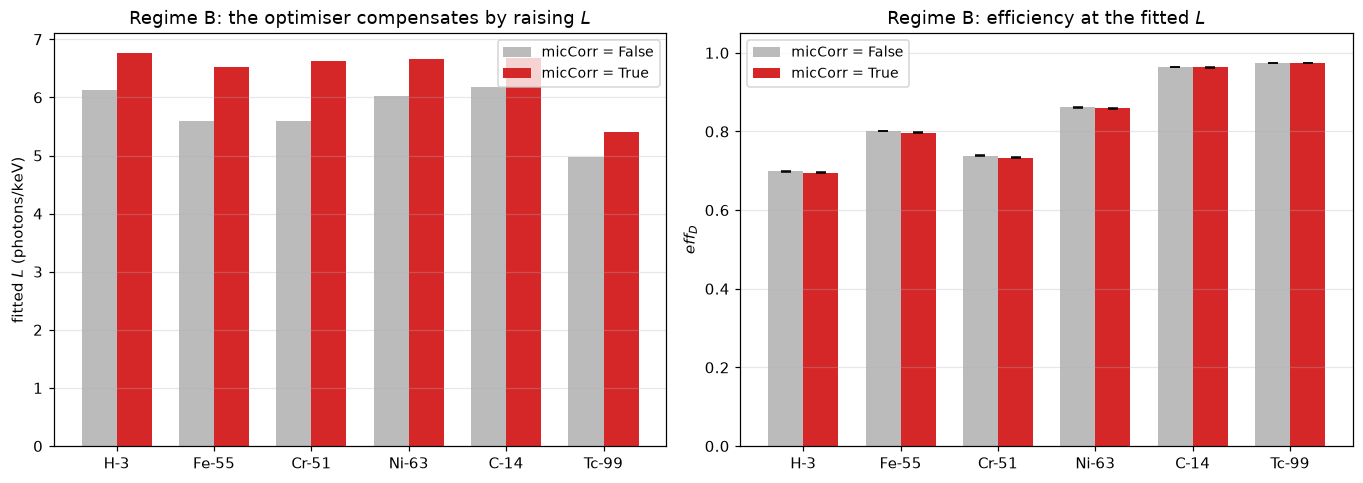

In [9]:
print(f'\nREGIME B -- L fitted to the measured TDCR, kB = 0.01 cm/MeV, '
      f'{COCKTAIL} + {FAQ:.0%} water, N = {N_MC}\n')
hdr = (f'{"nuclide":8s} {"TD":>6s} {"L off":>8s} {"L on":>8s} {"Delta_L %":>10s} '
       f'{"eff_D off":>11s} {"eff_D on":>11s} {"Delta_D %":>10s} {"n_sigma":>8s}')
print(hdr); print('-' * len(hdr))
tabB = {}
for rad in NUCLIDES:
    a, b = resB[rad][False], resB[rad][True]
    dL = relchange(a['L0'], b['L0']); dD = relchange(a['D'], b['D'])
    nsig = (b['D'] - a['D']) / np.hypot(a['uD'], b['uD'])
    tabB[rad] = (dL, dD, nsig)
    print(f'{rad:8s} {a["TD"]:6.2f} {a["L0"]:8.4f} {b["L0"]:8.4f} {dL:10.2f} '
          f'{a["D"]:11.5f} {b["D"]:11.5f} {dD:10.2f} {nsig:8.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
x = np.arange(len(NUCLIDES)); w = 0.36
axes[0].bar(x - w/2, [resB[r][False]['L0'] for r in NUCLIDES], w,
            color='#bbbbbb', label='micCorr = False')
axes[0].bar(x + w/2, [resB[r][True]['L0'] for r in NUCLIDES], w,
            color='#d62728', label='micCorr = True')
axes[0].set_xticks(x); axes[0].set_xticklabels(NUCLIDES)
axes[0].set_ylabel('fitted $L$ (photons/keV)')
axes[0].set_title('Regime B: the optimiser compensates by raising $L$')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, [resB[r][False]['D'] for r in NUCLIDES], w,
            yerr=[resB[r][False]['uD'] for r in NUCLIDES], capsize=3,
            color='#bbbbbb', label='micCorr = False')
axes[1].bar(x + w/2, [resB[r][True]['D'] for r in NUCLIDES], w,
            yerr=[resB[r][True]['uD'] for r in NUCLIDES], capsize=3,
            color='#d62728', label='micCorr = True')
axes[1].set_xticks(x); axes[1].set_xticklabels(NUCLIDES)
axes[1].set_ylabel('$eff_D$'); axes[1].set_ylim(0, 1.05)
axes[1].set_title('Regime B: efficiency at the fitted $L$')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.savefig('micelle_regimeB_efffit.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. What survives the calibration

The chart below is the headline result: the change in `eff_D` caused by
enabling `micCorr` **after** `L` has been re-fitted to the measured TDCR — the
way an activity measurement is actually made. Each bar carries its Monte-Carlo
uncertainty and, underneath, the significance of the shift. At N = 100 000 a
real effect of a few tenths of a percent is resolvable, so a bar consistent with
zero here is genuine evidence of cancellation rather than a limit of the
statistics.

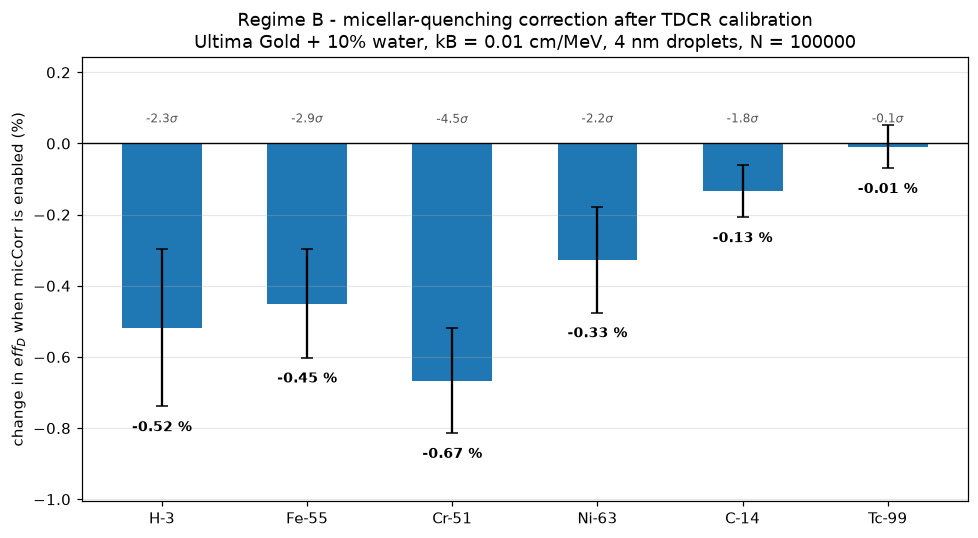

nuclide   <E_e> keV   TD meas |    L off     L on    d_L % |   d_effD %  n_sigma
----------------------------------------------------------------------------
H-3             5.7      0.67 |   6.1292   6.7672    10.41 |      -0.52     -2.3
Fe-55           5.2      0.57 |   5.5955   6.5213    16.55 |      -0.45     -2.9
Cr-51           4.4      0.48 |   5.5994   6.6315    18.43 |      -0.67     -4.5
Ni-63          17.4      0.88 |   6.0175   6.6653    10.77 |      -0.33     -2.2
C-14           49.5      0.97 |   6.1783   6.6848     8.20 |      -0.13     -1.8
Tc-99          84.6      0.98 |   4.9793   5.4092     8.63 |      -0.01     -0.1


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(NUCLIDES))
dB = [tabB[r][1] for r in NUCLIDES]
uB = [100 * np.hypot(resB[r][False]['uD'], resB[r][True]['uD']) / resB[r][False]['D']
      for r in NUCLIDES]
nsigB = [tabB[r][2] for r in NUCLIDES]

bars = ax.bar(x, dB, 0.55, yerr=uB, capsize=4, color='#1f77b4')
ax.axhline(0, color='k', lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(NUCLIDES)
ax.set_ylabel(r'change in $eff_D$ when micCorr is enabled (%)')
ax.set_title('Regime B - micellar-quenching correction after TDCR calibration\n'
             f'{COCKTAIL} + {FAQ:.0%} water, kB = 0.01 cm/MeV, '
             f'{DIAM:g} nm droplets, N = {N_MC}')
ax.grid(axis='y', alpha=0.3)

# annotate each bar with its value and its significance
span = max(abs(min(dB)), abs(max(dB))) or 1.0
for xi, (v, u, ns) in enumerate(zip(dB, uB, nsigB)):
    off = 0.06 * span * (-1 if v < 0 else 1)
    ax.text(xi, v + off + (u if v >= 0 else -u), f'{v:+.2f} %',
            ha='center', va='bottom' if v >= 0 else 'top',
            fontsize=9, fontweight='bold')
    ax.text(xi, -0.20 * span if v >= 0 else 0.10 * span, f'{ns:+.1f}$\\sigma$',
            ha='center', va='center', fontsize=8, color='#555555')
ax.margins(y=0.22)
plt.tight_layout(); plt.savefig('micelle_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"nuclide":8s} {"<E_e> keV":>10s} {"TD meas":>9s} | {"L off":>8s} '
      f'{"L on":>8s} {"d_L %":>8s} | {"d_effD %":>10s} {"n_sigma":>8s}')
print('-' * 76)
for rad in NUCLIDES:
    print(f'{rad:8s} {INFO[rad][1]:10.1f} {INFO[rad][0]:9.2f} | '
          f'{resB[rad][False]["L0"]:8.4f} {resB[rad][True]["L0"]:8.4f} '
          f'{tabB[rad][0]:8.2f} | {tabB[rad][1]:10.2f} {tabB[rad][2]:8.1f}')


## 5. How much does the size dispersion matter?

Everything above runs at the shipped default `sigma_micelle = 0`: a
**monodisperse** population in which every droplet carries the nominal radius.
That default follows the dynamic-light-scattering survey of commercial
cocktails by [D. E. Bergeron, *Determination of micelle size in some commercial
liquid scintillation cocktails*, Appl. Radiat. Isot. **70** (2012) 2164–2169]
(https://doi.org/10.1016/j.apradiso.2012.02.089): the size spread is small
compared with the mean, so the mean size is taken to carry the physics. That
work also found the hydrodynamic diameters to be substantially smaller than the
8 nm long treated as canonical, which is the basis for the `diam_micelle` used
here.

It is a modelling choice, and one worth testing rather than assuming. This
section varies `sigma_micelle` across the range that choice covers,
$\sigma/r_d$ = 0, 10, 20 and 30 % at $r_d$ = 2 nm, and adds the 50 % spread
TDCRPy shipped as its own default up to 2.20.20 as an out-of-range reference.

Three effects have to be kept apart, because $\sigma$ reaches them differently:

* the **plateau** $1-f_{Aq}$, which section 2.1 showed is independent of
  $\sigma$ *by construction* once $\lambda$ is built from $\langle r\rangle$ —
  so nothing is expected here, and seeing nothing is the check that the 2.20.19
  fix holds across the scan;
* the **confinement region** below a few keV, where the electron may never
  leave the droplet it was born in. Here the size genuinely matters, and
  because $f$ is a *non-linear* function of the radius, averaging over a
  distribution of radii is not the same as using the mean radius. This is the
  one place a dispersion can move the mean response;
* the **event-to-event spread** of the retained energy, which feeds the
  triple-to-double ratio rather than the mean light output.


  sigma = 0.0 nm  ->  plateau 0.9000


  sigma = 0.2 nm  ->  plateau 0.9000


  sigma = 0.4 nm  ->  plateau 0.9000


  sigma = 0.6 nm  ->  plateau 0.9000


  sigma = 1.0 nm  ->  plateau 0.9000


5 x 66 energies x 200000 samples in 477 s


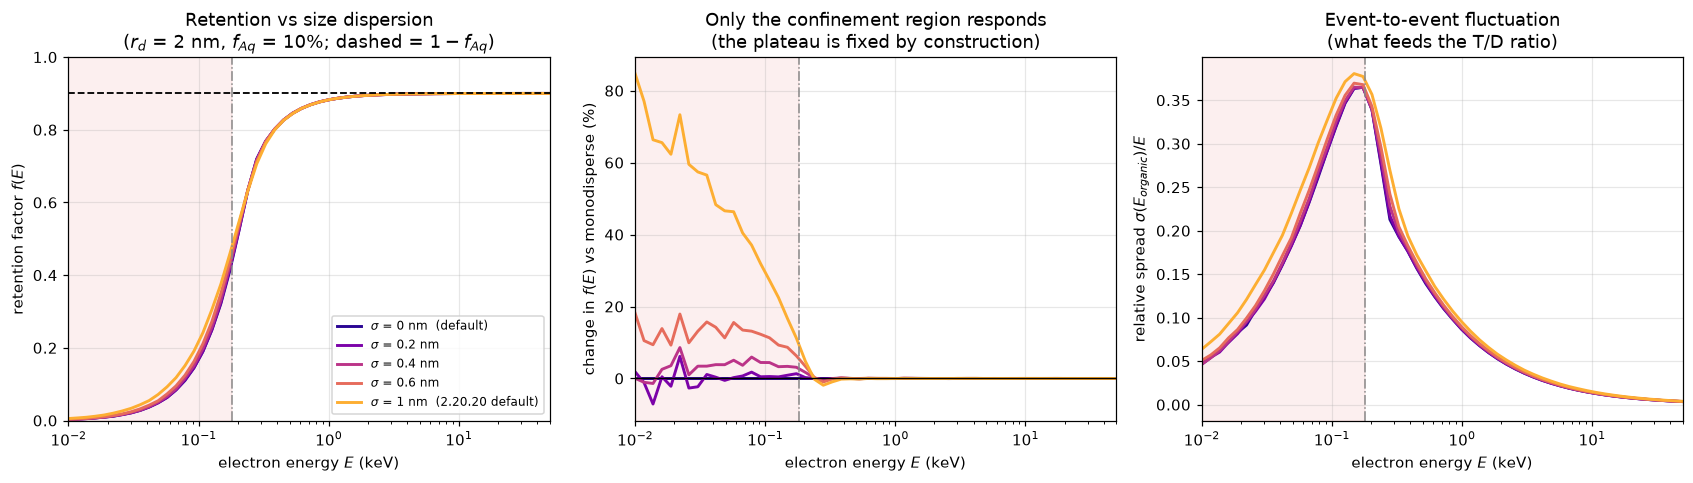

retention f(E)
  E (keV)       s=0     s=0.2     s=0.4     s=0.6       s=1
-----------------------------------------------------------
     0.02    0.0094    0.0092    0.0097    0.0103    0.0153
     0.05    0.0488    0.0486    0.0507    0.0543    0.0716
     0.09    0.1447    0.1454    0.1511    0.1625    0.1909
     0.15    0.3214    0.3243    0.3322    0.3493    0.3750
     0.20    0.5199    0.5212    0.5286    0.5375    0.5448
     0.28    0.7196    0.7181    0.7159    0.7126    0.7060
     0.53    0.8457    0.8451    0.8449    0.8456    0.8442
     0.99    0.8825    0.8822    0.8823    0.8824    0.8823
     4.86    0.8989    0.8989    0.8987    0.8989    0.8988
    98.85    0.9000    0.9000    0.9000    0.9000    0.9000

relative spread sigma(E_org)/E
  E (keV)       s=0     s=0.2     s=0.4     s=0.6       s=1
-----------------------------------------------------------
     0.02    0.0827    0.0815    0.0838    0.0863    0.1056
     0.05    0.1828    0.1824    0.1858    0.1917    

In [11]:
# 5.1  Where sigma acts on a single electron.
set_state(False)                        # sigma is passed explicitly below;
mc = tl.pure_mc_efficient_energy_numba  # only the module binding matters here

SIG_LIST = SIGMA_SCAN + [SIGMA_WIDE]
E_d  = np.logspace(np.log10(0.01), np.log10(300), 66)   # down to 10 eV, so
                                        # the weighted means of 5.2 do not
                                        # clamp the softest Auger electrons
NS_D = 200000                           # samples per (energy, sigma) point:
                                        # enough to resolve the sub-percent
                                        # dip just above the threshold

f_sig, s_sig = {}, {}
t0 = time.time()
for s in SIG_LIST:
    f = np.empty_like(E_d); sd = np.empty_like(E_d)
    for i, E in enumerate(E_d):
        m, v, _ = mc(E, r_d_nm=R_D, sigma_r=s, f_w=FAQ, num_samples=NS_D)
        f[i], sd[i] = m / E, v / E
    f_sig[s], s_sig[s] = f, sd
    print(f'  sigma = {s:3.1f} nm  ->  plateau {np.mean(f[E_d > 100]):.4f}',
          flush=True)
print(f'{len(SIG_LIST)} x {len(E_d)} energies x {NS_D} samples in '
      f'{time.time()-t0:.0f} s')

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))
cols = plt.cm.plasma(np.linspace(0.05, 0.82, len(SIG_LIST)))
for c, s in zip(cols, SIG_LIST):
    tag = ('  (default)' if s == 0.0 else
           '  (2.20.20 default)' if s == SIGMA_WIDE else '')
    lab = f'$\\sigma$ = {s:g} nm{tag}'
    axes[0].plot(E_d, f_sig[s], '-', color=c, lw=1.9, label=lab)
    axes[1].plot(E_d, 100 * (f_sig[s] - f_sig[0.0]) / f_sig[0.0], '-',
                 color=c, lw=1.9)
    axes[2].plot(E_d, s_sig[s], '-', color=c, lw=1.9)

for ax in axes:
    ax.set_xscale('log'); ax.set_xlim(E_d[0], 50)
    ax.axvline(E_conf, color='#888888', lw=1.0, ls='-.')
    ax.set_xlabel('electron energy $E$ (keV)'); ax.grid(alpha=0.3)

axes[0].axhline(1 - FAQ, color='k', ls='--', lw=1.2)
axes[0].axvspan(E_d[0], E_conf, color='#d62728', alpha=0.07)
axes[0].set_ylabel(r'retention factor $f(E)$'); axes[0].set_ylim(0, 1.0)
axes[0].set_title(f'Retention vs size dispersion\n'
                  f'($r_d$ = {R_D:g} nm, $f_{{Aq}}$ = {FAQ:.0%}; dashed = '
                  f'$1-f_{{Aq}}$)')
axes[0].legend(fontsize=8, loc='lower right')

axes[1].axhline(0, color='k', lw=0.9)
axes[1].axvspan(E_d[0], E_conf, color='#d62728', alpha=0.07)
axes[1].set_ylabel('change in $f(E)$ vs monodisperse (%)')
axes[1].set_title('Only the confinement region responds\n'
                  '(the plateau is fixed by construction)')

axes[2].axvspan(E_d[0], E_conf, color='#d62728', alpha=0.07)
axes[2].set_ylabel(r'relative spread $\sigma(E_{organic})/E$')
axes[2].set_title('Event-to-event fluctuation\n(what feeds the T/D ratio)')

plt.tight_layout()
plt.savefig('micelle_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

cols_hdr = ''.join(f'{"s=" + format(s, "g"):>10s}' for s in SIG_LIST)
print(f'retention f(E)\n{"E (keV)":>9s}{cols_hdr}')
print('-' * (9 + 10 * len(SIG_LIST)))
for E in (0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0, 5.0, 100.0):
    j = int(np.argmin(abs(E_d - E)))
    print(f'{E_d[j]:9.2f}' + ''.join(f'{f_sig[s][j]:10.4f}' for s in SIG_LIST))
print(f'\nrelative spread sigma(E_org)/E\n{"E (keV)":>9s}{cols_hdr}')
print('-' * (9 + 10 * len(SIG_LIST)))
for E in (0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0, 5.0, 100.0):
    j = int(np.argmin(abs(E_d - E)))
    print(f'{E_d[j]:9.2f}' + ''.join(f'{s_sig[s][j]:10.4f}' for s in SIG_LIST))


The middle panel is the whole story of this section: **the dispersion moves the
mean retention only in the confinement region**, below about 0.3 keV, and the
plateau sits at 0.9000 for every $\sigma$ tested — the 2.20.19 fix holds right
across the scan, as it must.

The sign is the opposite of what "extra spread means extra quenching" would
suggest. Deep in the confinement regime ($R(E) \lesssim r_d$) the escape
probability is a strongly **convex** function of the droplet radius: halving the
radius helps far more than doubling it hurts, since a small droplet offers its
contents a much larger surface for the volume they occupy. Averaging over a
distribution of radii therefore lands *above* the value at the mean radius —
Jensen's inequality — and the retention **rises** with $\sigma$:

| $E$ (keV) | 0.02 | 0.05 | 0.09 | 0.15 | 0.20 | 0.28 | $\geq$ 0.5 |
|---|---|---|---|---|---|---|---|
| $\sigma$ = 0.6 nm | +9.6 % | +11.3 % | +12.3 % | +8.7 % | +3.4 % | −1.0 % | 0 |
| $\sigma$ = 1.0 nm | +63 % | +47 % | +32 % | +17 % | +4.8 % | −1.9 % | 0 |

Just above the threshold, near 0.28 keV, the curvature changes sign and the
effect turns slightly negative before dying out altogether above ~0.5 keV.

**The spread behaves differently from the mean, and this is worth noting.**
The right-hand panel rises with $\sigma$ at *every* energy, not just in the
confinement region: the relative spread grows by about 4–5 % at
$\sigma$ = 0.6 nm and 10–16 % at $\sigma$ = 1 nm, from 0.3 keV all the way to
100 keV. A long track crosses many droplets, and drawing each of their sizes
independently adds variance to the total aqueous path even when it leaves the
*mean* aqueous path untouched. So a size distribution does reach the
triple-to-double ratio, through a channel the mean retention cannot show —
which is why section 5.3 has to check the calibrated efficiencies rather than
stopping at section 5.2.

Two features of the sampling bound how far any of this can be pushed. Radii are
drawn **independently at every encounter**, including for the droplet the decay
starts in, so what is plotted is the pure convexity effect: the model applies no
cross-section weighting to the droplets an electron crosses, and no volume
weighting to the one it is born in. Both would bias the sampled sizes upward and
work against the rise seen here. They would matter for a broad distribution, and
not at all for a monodisperse one.


nuclide       n_e  <E_e> keV  E<1 keV %
------------------------------------------


H-3         19890       3.58       2.70   [43 s]


Fe-55       52275       1.17      10.60   [315 s]


Cr-51       52934       1.32       8.42   [319 s]


Ni-63       19807      13.33       0.30   [35 s]


C-14        19864      42.93       0.03   [31 s]


Tc-99       19877      90.99       0.01   [31 s]


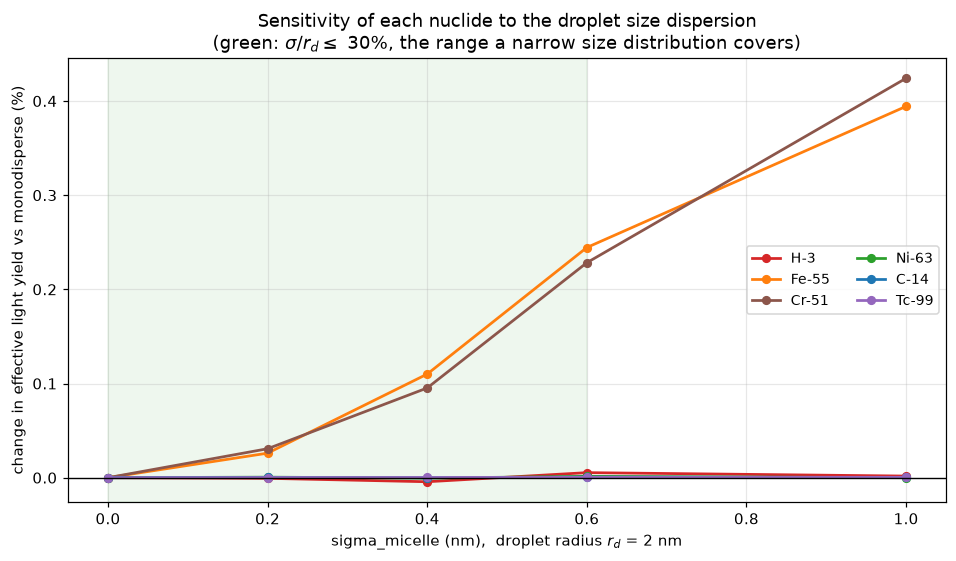

change in effective light yield vs the monodisperse default (%)
nuclide   E<1keV %       s=0     s=0.2     s=0.4     s=0.6       s=1
--------------------------------------------------------------------
H-3           2.70     0.000    -0.001    -0.004     0.005     0.002
Fe-55        10.60     0.000     0.026     0.110     0.244     0.394
Cr-51         8.42     0.000     0.031     0.095     0.228     0.424
Ni-63         0.30     0.000     0.001    -0.000     0.001    -0.000
C-14          0.03     0.000     0.000    -0.000     0.001     0.000
Tc-99         0.01     0.000     0.000     0.000     0.000     0.000


In [12]:
# 5.2  What the dispersion does to each nuclide.
# The kernel acts on every Birks-quenched electron energy, so the light a decay
# produces scales with the ENERGY-WEIGHTED mean retention
#     F = sum_i f(E_i) E_i / sum_i E_i
# over the electrons TDCRPy actually generates. Comparing F between two values
# of sigma gives the change in effective light yield directly, without the MC
# noise that an eff() re-fit adds on top of it.

def electron_energies(rad, n=N_REC):
    '''Birks-quenched electron energies (keV) recorded over n decays.'''
    set_state(False)                                  # micCorr off: these are
    tm.TDCRPy(2.0, rad, '1', n, KB, V, record=True)   # the energies the micelle
    E = []                                            # kernel would be handed
    with open(tl.record_file_path(2)) as fh:
        for line in fh:
            if line.startswith('#'):
                continue
            p = line.split()
            if len(p) == 5 and p[0] == '1':           # KPAR 1 = electron
                e = float(p[1]) * 1e-3                # eV -> keV
                if e > 0:
                    E.append(e)
    return np.asarray(E)


Fw = {}
print(f'{"nuclide":8s} {"n_e":>8s} {"<E_e> keV":>10s} {"E<1 keV %":>10s}')
print('-' * 42)
for rad in NUCLIDES:
    t0 = time.time()
    Ee = electron_energies(rad)
    Fw[rad] = {s: float(np.sum(np.interp(Ee, E_d, f_sig[s]) * Ee) / np.sum(Ee))
               for s in SIG_LIST}
    Fw[rad]['sub1'] = 100.0 * np.sum(Ee[Ee < 1.0]) / np.sum(Ee)
    print(f'{rad:8s} {len(Ee):8d} {Ee.mean():10.2f} {Fw[rad]["sub1"]:10.2f}   '
          f'[{time.time()-t0:.0f} s]', flush=True)
tl.cleanup_record_files()

fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.axvspan(0, max(SIGMA_SCAN), color='#2ca02c', alpha=0.08)
for rad in NUCLIDES:
    y = [100 * (Fw[rad][s] - Fw[rad][0.0]) / Fw[rad][0.0] for s in SIG_LIST]
    ax.plot(SIG_LIST, y, 'o-', color=COLORS[rad], lw=1.8, ms=5, label=rad)
ax.axhline(0, color='k', lw=0.9)
ax.set_xlabel(f'sigma_micelle (nm),  droplet radius $r_d$ = {R_D:g} nm')
ax.set_ylabel('change in effective light yield vs monodisperse (%)')
ax.set_title('Sensitivity of each nuclide to the droplet size dispersion\n'
             f'(green: $\\sigma/r_d \\leq$ {max(SIGMA_SCAN)/R_D:.0%}, the range '
             f'a narrow size distribution covers)')
ax.legend(fontsize=9, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('micelle_dispersion_nuclides.png', dpi=150, bbox_inches='tight')
plt.show()

print('change in effective light yield vs the monodisperse default (%)')
print(f'{"nuclide":8s} {"E<1keV %":>9s}' +
      ''.join(f'{"s=" + format(s, "g"):>10s}' for s in SIG_LIST))
print('-' * (18 + 10 * len(SIG_LIST)))
for rad in NUCLIDES:
    row = ''.join(f'{100 * (Fw[rad][s] - Fw[rad][0.0]) / Fw[rad][0.0]:10.3f}'
                  for s in SIG_LIST)
    print(f'{rad:8s} {Fw[rad]["sub1"]:9.2f}{row}')


The size dispersion reaches a nuclide in exact proportion to how much of its
energy is carried by sub-keV electrons — the second column. The $\beta$
emitters above C-14 put essentially none of their energy there and are
untouched at any $\sigma$; the Auger cascades of Fe-55 and Cr-51 put about a
tenth of theirs there and respond.

The number that matters for a measurement is not the shift itself but the
**spread of the shift across nuclides**, since a change common to all of them
is degenerate with the light yield `L` and is reabsorbed by the calibration.


In [13]:
# 5.3  Does any of it survive the TDCR calibration?
# sigma enters through the micelle kernel only, so the micCorr = False arm of
# section 3 does not depend on it and serves as the common reference. Only the
# corrected arm is recomputed, at the widest spread the default covers.
resD = {}
for rad in NUCLIDES:
    resD[rad] = run_effopt(rad, True, sigma=SIGMA_TEST)
    r = resD[rad]
    flag = 'ok' if r['converged'] else '*** FIT DID NOT CONVERGE ***'
    print(f'{rad:6s} sigma={SIGMA_TEST:g} micCorr=True  L0={r["L0"]:7.4f}  '
          f'D={r["D"]:.5f}+-{r["uD"]:.5f}  TDCR_fit={r["TDCR"]:.5f}  {flag}   '
          f'[{r["t"]:.0f} s]', flush=True)

bad = [rad for rad in NUCLIDES if not resD[rad]['converged']]
print('\nAll fits converged.' if not bad else f'\nNON-CONVERGED: {bad}')

print(f'\nEffect of the size dispersion AFTER calibration: sigma 0 -> '
      f'{SIGMA_TEST:g} nm, micCorr = True, N = {N_MC}\n')
hdr = (f'{"nuclide":8s} {"L(s=0)":>8s} {"L(s>0)":>8s} {"d_L %":>7s} '
       f'{"effD(s=0)":>10s} {"effD(s>0)":>10s} {"d_effD %":>9s} '
       f'{"n_sigma":>8s} {"d_light %":>10s}')
print(hdr); print('-' * len(hdr))
for rad in NUCLIDES:
    a, b = resB[rad][True], resD[rad]
    ns = (b['D'] - a['D']) / np.hypot(a['uD'], b['uD'])
    dlight = 100 * (Fw[rad][SIGMA_TEST] - Fw[rad][0.0]) / Fw[rad][0.0]
    print(f'{rad:8s} {a["L0"]:8.4f} {b["L0"]:8.4f} '
          f'{relchange(a["L0"], b["L0"]):7.2f} {a["D"]:10.5f} {b["D"]:10.5f} '
          f'{relchange(a["D"], b["D"]):9.3f} {ns:8.1f} {dlight:10.3f}')

res_mc = 100 * np.mean([np.hypot(resB[r][True]['uD'], resD[r]['uD']) /
                        resB[r][True]['D'] for r in NUCLIDES])
print(f'\n1-sigma MC resolution on d_effD at N = {N_MC}, two independent '
      f'runs: +-{res_mc:.2f} %')


H-3    sigma=0.6 micCorr=True  L0= 6.7495  D=0.69722+-0.00109  TDCR_fit=0.66830  ok   [277 s]


Fe-55  sigma=0.6 micCorr=True  L0= 6.5074  D=0.79839+-0.00087  TDCR_fit=0.57000  ok   [2417 s]


Cr-51  sigma=0.6 micCorr=True  L0= 6.6077  D=0.73447+-0.00077  TDCR_fit=0.47700  ok   [2475 s]


Ni-63  sigma=0.6 micCorr=True  L0= 6.6496  D=0.85829+-0.00091  TDCR_fit=0.88060  ok   [237 s]


C-14   sigma=0.6 micCorr=True  L0= 6.8743  D=0.96299+-0.00051  TDCR_fit=0.97000  ok   [212 s]


Tc-99  sigma=0.6 micCorr=True  L0= 5.3132  D=0.97468+-0.00042  TDCR_fit=0.98000  ok   [246 s]



All fits converged.

Effect of the size dispersion AFTER calibration: sigma 0 -> 0.6 nm, micCorr = True, N = 100000

nuclide    L(s=0)   L(s>0)   d_L %  effD(s=0)  effD(s>0)  d_effD %  n_sigma  d_light %
--------------------------------------------------------------------------------------
H-3        6.7672   6.7495   -0.26    0.69546    0.69722     0.253      1.1      0.005
Fe-55      6.5213   6.5074   -0.21    0.79718    0.79839     0.152      1.0      0.244
Cr-51      6.6315   6.6077   -0.36    0.73370    0.73447     0.105      0.7      0.228
Ni-63      6.6653   6.6496   -0.24    0.85873    0.85829    -0.051     -0.3      0.001
C-14       6.6848   6.8743    2.83    0.96284    0.96299     0.016      0.2      0.001
Tc-99      5.4092   5.3132   -1.77    0.97484    0.97468    -0.017     -0.3      0.000

1-sigma MC resolution on d_effD at N = 100000, two independent runs: +-0.14 %


`d_light %` is the section 5.2 prediction — what the dispersion does to the
light budget before anything is refitted — and `d_effD %` is what is left of it
once `L` has been re-fitted to the same measured TDCR.

**Nothing survives.** Every nuclide lands within 0.25 % and within 1.1σ of zero,
against a 1σ Monte-Carlo resolution of ±0.14 % on this comparison. The clearest
sign that what is left is noise rather than signal is that the *largest*
`d_effD` belongs to **H-3** (+0.25 %, 1.1σ) — the nuclide whose light yield
section 5.2 says the dispersion changes by 0.005 %, i.e. not at all. Meanwhile
Fe-55 and Cr-51, which do pick up a real +0.24 % and +0.23 % of light, come out
at +0.15 % and +0.11 %, both under 1σ.

So at the widest spread the default covers — $\sigma/r_d$ = 30 % — the size
dispersion is **not resolvable in a calibrated efficiency at N = 100 000**, even
for the two nuclides that are sensitive to it. Taking `sigma_micelle` to zero
costs nothing measurable, and buys a model with no truncation question and no
dependence on the shape of a size distribution nobody has measured for these
cocktails.


## 6. Conclusions

**1. The TD set is self-consistent, and the fits confirm it.** In the
uncorrected arm the fitted light yields come out at 6.129 (H-3), 6.018 (Ni-63)
and 6.178 (C-14) for the three tied to the C-14 anchor — a 2.7 % spread — and
at 5.596 (Fe-55) and 5.599 (Cr-51) for the pair tied to Fe-55, agreeing to
0.07 %. That is the round-trip check: the inference of section 1.1 ran at
N = 20 000 and these fits at N = 100 000, through `eff()`.

Tc-99 is the one genuinely independent input, and it lands at **4.979** — a
light yield 19 % below the one C-14 implies. So the three quoted measurements
are only roughly mutually consistent: either the counter was not the same, or
one of the ratios is off by a little. Being able to see that is itself useful.

**2. Under TDCR calibration the correction is largely absorbed into `L`, but
not entirely.** Enabling `micCorr` raises the fitted yield by **8 % to 18 %**,
and the recalculated `eff_D` then moves by **less than 0.7 %**, always
downwards:

| nuclide | `eff_D` | Δ`L` % | Δ`eff_D` % | significance |
|---|---|---|---|---|
| H-3 | 0.699 | +10.4 | −0.52 | −2.3σ |
| Fe-55 | 0.801 | +16.6 | −0.45 | −2.9σ |
| Cr-51 | 0.739 | +18.4 | **−0.67** | **−4.5σ** |
| Ni-63 | 0.862 | +10.8 | −0.33 | −2.2σ |
| C-14 | 0.964 | +8.2 | −0.13 | −1.8σ |
| Tc-99 | 0.975 | +8.6 | −0.01 | −0.1σ |

Read the *sign* and the *magnitude* as robust and the *ranking* as not: the
significances quoted are within-run, and the reproducibility caveat below shows
they are optimistic.

**3. Two different things are going on, and they order the nuclides
differently.**

*The shape distortion* is carried by the **electron-capture** nuclides. Fe-55
and Cr-51 need a 17–18 % increase in `L` where every β emitter needs 8–11 %,
and their calibration curves are displaced far more at a common
`L` = 8 photons/keV:

| Cr-51 | Fe-55 | H-3 | Ni-63 | C-14 | Tc-99 |
|---|---|---|---|---|---|
| **−12.9 %** | **−9.8 %** | −1.8 % | −1.5 % | −0.20 % | −0.06 % |

Their signal is Auger electrons of a few keV — inside the confinement regime of
section 2 — and their X-rays frequently escape the vial, leaving a large
population of near-zero deposits exactly where the correction bites. A displaced
curve cannot be undone by refitting `L`.

*The residual efficiency bias*, by contrast, tracks **how far the nuclide is
from saturation**, not its decay mode. Ordered by `eff_D` — 0.699, 0.739,
0.801, 0.862, 0.964, 0.975 — the residual falls from ~0.6 % to 0.01 %. The
trend across the range is clear; the ordering *within* the three
low-efficiency nuclides (−0.52, −0.67, −0.45 %) is not resolved, since they sit
within the run-to-run reproducibility of each other. Where the efficiency curve
is still steep, the cancellation between a reduced photon budget and a raised
`L` is imperfect; where the nuclide has saturated, there is nothing left to
cancel.

**4. The droplet size dispersion does not matter, and that is now measured
rather than assumed.** Section 5 varies `sigma_micelle` from 0 to 30 % of the
droplet radius, and the 50 % spread TDCRPy shipped up to 2.20.20 as a reference:

* the **plateau** stays at 0.9000 throughout, at every radius from 1 to 8 nm;
* the **mean retention** moves only below ~0.3 keV, and *upwards* — the escape
  probability is convex in the radius, so averaging over sizes helps the
  electron escape more often than it hurts;
* the **effective light yield** of a whole decay therefore changes by at most
  **+0.24 %** (Fe-55) and **+0.23 %** (Cr-51) at $\sigma/r_d$ = 30 %, and by
  less than 0.005 % for H-3, Ni-63, C-14 and Tc-99. A nuclide feels the
  dispersion in exact proportion to the fraction of its energy carried by
  sub-keV electrons: 10.6 % for Fe-55 and 8.4 % for Cr-51 against 0.01–2.7 %
  for the rest;
* **after calibration nothing survives**: every nuclide is within 0.25 % and
  1.1σ of zero, against a ±0.14 % resolution at N = 100 000.

The monodisperse default is therefore free. It also removes a modelling
liability: with $\sigma$ = 0 the sampled radius is strictly positive, so the
zero-truncation question that section 2.1 had to fix cannot arise, and no
result depends on whether the size distribution is Gaussian, log-normal or
anything else.

**Practical guidance.**

* For a well-performing counter (`L` ≈ 6 photons/keV, i.e. ~1.5 photoelectrons
  per keV per PMT) at a 10 % aqueous load, enabling `micCorr` changes the
  reported efficiency by **well under 1 %** for every nuclide here — but that
  shift is systematic and always negative, and should not be dismissed as
  noise.
* The fitted `L` is **not** interchangeable between the two settings: it absorbs
  the correction and shifts by 8–18 %, most for the EC nuclides. An `L`
  obtained with `micCorr = True` must not be reused with it off, nor
  transferred to a nuclide measured the other way.
* Check where your nuclide sits on its efficiency curve. Near saturation the
  correction cancels almost perfectly; on the steep part it does not.
* Leave `sigma_micelle` at 0 unless you have a measured size distribution for
  your cocktail; section 5 shows the cost of doing so is below what a
  100 000-decay calibration can resolve.
* At **fixed `L`** none of this cancellation applies and the full several-percent
  effect is in play.
* Always pair `micCorr` with a correct `fAq`: the bulk composition effect (not
  studied here; see
  [`cocktailComposition.ipynb`](../advanced/cocktailComposition.ipynb)) is the
  larger of the two.

### Caveats on the current implementation

* **Δ`eff_D` is less reproducible than its quoted significance suggests.** The
  `uD` returned by `eff()` is the binomial Monte-Carlo uncertainty *at the
  fitted `L`*; it carries nothing from the uncertainty of the `L` fit itself,
  nor from the TD set being re-inferred at N = 20 000 in each run. The evidence
  is direct: an earlier full run of this notebook at $\sigma$ = 1 nm — which
  section 5.2 shows differs from $\sigma$ = 0 by 0.002 % in H-3's light yield,
  i.e. the same physics — returned Δ`eff_D` = −0.97 % for H-3 where this run
  returns −0.52 %. That is 0.45 percentage points apart, about three times the
  ±0.14 % quoted. Treat the per-nuclide values as good to a few tenths of a
  percent, not to the last digit.
* **An inferred TD inherits the anchor's uncertainty, amplified.** Cr-51 sits on
  a steep part of its TDCR-vs-`L` curve, so a few percent of difference in the
  anchor `L` found at N = 20 000 moves its inferred TD appreciably. Inferred
  ratios are a way of building a coherent set, not a substitute for measuring
  the nuclide.
* **`eff()`'s default `Lbounds=(0.1, 100)` is not safe for every nuclide.** The
  modelled TDCR is not monotonic in `L` (section 3.1): it turns over near
  `L` ≈ 23 for Fe-55 and ≈ 29 for Cr-51, because their escaping X-rays leave
  many near-zero deposits that the *doubles* recover long before they can fire
  three PMTs, so `eff_D` climbs toward 1 faster than `eff_T`. The bounded
  search can settle into a spurious minimum against the upper bound and return
  an `L` reproducing the wrong TDCR, with no error and no warning. Bracket `L`
  and check `eff_T/eff_D` against the TD you asked for, as `run_effopt()` does.
* **`diam_micelle` was being used as a radius by the stochastic kernel up to
  2.20.20**, while `micelleLoss()` read the same key as a diameter to index the
  Nedjadi table — so the two micelle models in TDCRPy disagreed by a factor two
  on the same configuration. Fixed in 2.20.21: the kernel now takes
  `diam_micelle / 2` as the radius, and the shipped default moved from 2 to
  **4 nm diameter** so the droplet size is unchanged (2 nm radius). Any
  `diam_micelle` written by hand for 2.20.20 or earlier means half what it now
  means, and has to be doubled.
* **The record/replay files were a fixed name in the shared system temp
  directory** up to and including 2.20.19. Two TDCRPy processes on one machine
  overwrote each other's decay histories, and because `_run_from_history`
  silently skips the resulting malformed lines, the corruption biased results
  instead of raising. **Fixed in 2.20.20**: the names now carry the writing
  process's PID (`Temp_E2_<pid>.txt`, see `TDCR_model_lib.record_file_path`),
  so concurrent runs cannot collide; `cleanup_record_files()` removes them when
  you are done. This run was additionally given its own `TEMP`.
* `config.toml` lives inside the installed package and is **still** shared
  between concurrent processes, so two runs can overwrite each other's
  parameters. A private `TEMP` does not isolate it.
* The quenching path calls `pure_mc_efficient_energy_numba(eq)` with its
  defaults and reads `fAq`, `diam_micelle` and `sigma_micelle` as *keyword
  defaults bound at import time*, so changing them with `modify*()` requires an
  `importlib.reload` — which is what `set_state()` above does.
* The kernel draws every droplet radius **independently**, including the one the
  decay starts in. A physical treatment would weight the droplets an electron
  crosses by their cross-section ($r^2$) and the one it starts in by its volume
  ($r^3$). Both are identities at $\sigma$ = 0, so the default is unaffected;
  they would matter only for a broad size distribution.
* Enabling `micCorr` costs roughly a factor 2–7 in runtime: the kernel is
  declared `@njit(parallel=True)` but the quenching path calls it with
  `num_samples=1`, so each call pays the thread-team setup for one `prange`
  iteration.
* `micelleLoss()` — the legacy deterministic GEANT4-DNA lookup — is still
  present but is no longer called by the quenching path.


In [14]:
# Restore the configuration exactly as it was before this notebook ran.
_quiet(tl.modifyLScocktail, NOMINAL['ls_cocktail'], NOMINAL['fAq'],
       NOMINAL['solvantType'], NOMINAL['solvantConc'])
tl.modifyDiam_micelle(NOMINAL['diam_micelle'])
tl.modifySigma_micelle(NOMINAL['sigma_micelle'])
tl.modifyMicCorr(NOMINAL['micCorr'])
tl = importlib.reload(tl); tm = importlib.reload(tm)
print('config.toml restored:')
print(f'  ls_cocktail   = {NOMINAL["ls_cocktail"]}')
print(f'  fAq           = {tl.fAq}')
print(f'  micCorr       = {tl.micCorr}')
print(f'  diam_micelle  = {tl.diam_micelle}')
print(f'  sigma_micelle = {tl.sigma_micelle}')

config.toml restored:
  ls_cocktail   = Ultima Gold
  fAq           = 0.0
  micCorr       = False
  diam_micelle  = 4.0
  sigma_micelle = 0.0
